# Reto 02 — Comparación de algoritmos para Multi-Armed Bandits

**Integrantes:** Simon Garces  \n**Correos:** simon.garces@eia.edu.co  \n**Fecha:** 2026-07-25

## Objetivo

Describe el objetivo del experimento y la pregunta que deseas responder.

## 1. Preparación del entorno

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# El kernel de Jupyter arranca en la carpeta del notebook, no en la raiz del
# repositorio, asi que "import challenges..." falla. Subimos carpetas hasta
# encontrar el pyproject.toml y agregamos esa raiz al sys.path.
_repo_root = Path.cwd()
while not (_repo_root / "pyproject.toml").exists() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from challenges.challenge_02_bandit_algorithms.starter_code import (
    GaussianBandit,
    cumulative_average,
    cumulative_regret,
    optimal_action_rate,
)

SEED = 2026
HORIZON = 1_000
N_RUNS = 100
MEANS = np.array([1.0, 2.0, 1.5])
STDS = np.array([0.5, 0.5, 1.5])
ARM_NAMES = np.array(["A1", "A2", "A3"])

## 2. Verificación del bandit

Crea el entorno, muestra sus propiedades y explica por qué A2 es el brazo óptimo.

In [2]:
bandit = GaussianBandit(MEANS, STDS, seed=SEED)
print(f"Número de brazos: {bandit.n_arms}")
print(f"Brazo óptimo: {ARM_NAMES[bandit.optimal_arm]}")
print(f"Media óptima: {bandit.optimal_mean}")

Número de brazos: 3
Brazo óptimo: A2
Media óptima: 2.0


## 3. Funciones auxiliares

Implementa actualización incremental y selección aleatoria entre empates.

In [3]:
def random_argmax(values: np.ndarray, rng: np.random.Generator) -> int:
    # np.max encuentra el valor máximo del arreglo.
    best_value = np.max(values)
    # np.flatnonzero devuelve TODOS los índices donde values == best_value,
    # es decir, todos los brazos empatados en el máximo (puede ser solo uno).
    best_indices = np.flatnonzero(values == best_value)
    # rng.choice elige uno de esos índices al azar, para no favorecer
    # siempre al primer brazo cuando hay empate.
    return int(rng.choice(best_indices))


def incremental_update(estimate: float, reward: float, count: int) -> float:
    # Media incremental: Q_nuevo = Q_viejo + (recompensa - Q_viejo) / conteo.
    # Esto evita tener que guardar y volver a promediar todo el historial.
    return estimate + (reward - estimate) / count

## 4. ε-greedy

In [4]:
def run_epsilon_greedy(
    *,
    epsilon: float,
    initial_value: float,
    horizon: int,
    seed: int,
) -> pd.DataFrame:
    # Validamos que epsilon sea una probabilidad válida (entre 0 y 1).
    if not (0.0 <= epsilon <= 1.0):
        raise ValueError("epsilon debe estar entre 0 y 1.")
    # El horizonte (número de pasos) debe ser un entero positivo.
    if horizon <= 0:
        raise ValueError("horizon debe ser positivo.")

    # Creamos el entorno con la semilla dada: sus recompensas serán
    # reproducibles si se vuelve a usar la misma semilla.
    bandit = GaussianBandit(MEANS, STDS, seed=seed)
    # Usamos un generador aleatorio propio (independiente del bandit)
    # para las decisiones del algoritmo: exploración y desempates.
    rng = np.random.default_rng(seed)

    n_arms = bandit.n_arms
    # Inicializamos todas las estimaciones Q(a) en initial_value.
    q_values = np.full(n_arms, float(initial_value))
    # counts guarda cuántas veces se ha seleccionado cada brazo.
    counts = np.zeros(n_arms, dtype=int)

    # Aquí guardamos una fila de historial por cada paso jugado.
    rows = []
    for t in range(1, horizon + 1):
        # rng.random() genera un número entre 0 y 1: si es menor que
        # epsilon, exploramos (acción aleatoria); si no, explotamos.
        if rng.random() < epsilon:
            action = int(rng.integers(n_arms))
        else:
            action = random_argmax(q_values, rng)

        # Jugamos el brazo elegido y obtenemos una recompensa real.
        reward = bandit.pull(action)

        # Actualizamos el conteo y la estimación Q del brazo jugado.
        counts[action] += 1
        q_values[action] = incremental_update(q_values[action], reward, counts[action])

        # Guardamos el paso, la acción, la recompensa y las estimaciones
        # actuales de cada brazo (columnas q_a1, q_a2, q_a3).
        row = {"step": t, "action": action, "reward": reward}
        for arm_index, arm_name in enumerate(ARM_NAMES):
            row[f"q_{arm_name.lower()}"] = q_values[arm_index]
        rows.append(row)

    # Convertimos la lista de filas en un DataFrame: una fila por paso.
    return pd.DataFrame(rows)

## 5. ε-greedy con inicio optimista

Reutiliza la implementación anterior con ε = 0 y Q0 = 5. Explica el mecanismo de exploración.

In [5]:
# Prueba corta: epsilon=0 (sin exploración aleatoria) e initial_value alto (5.0),
# muy por encima de las recompensas reales (máximo 2.0). Como cada estimación
# empieza "decepcionantemente alta", el algoritmo prueba brazos distintos
# aunque epsilon sea 0: a esto se le llama exploración por inicio optimista.
optimistic_test_df = run_epsilon_greedy(
    epsilon=0.0,
    initial_value=5.0,
    horizon=20,
    seed=SEED,
)

print(optimistic_test_df[["step", "action", "reward"]])

# Contamos cuántas veces se jugó cada brazo en estos 20 pasos: si el
# mecanismo funciona, los tres brazos deben haberse probado al menos una vez.
print("\nVeces que se jugó cada brazo:")
print(optimistic_test_df["action"].value_counts().sort_index())

    step  action    reward
0      1       0  0.603439
1      2       2  1.860857
2      3       1  1.051837
3      4       2  3.593658
4      5       2  2.457442
5      6       2  1.061929
6      7       2  1.032076
7      8       2  1.955753
8      9       2  1.098510
9     10       2  1.161137
10    11       2  2.580102
11    12       2  2.272058
12    13       2  1.403808
13    14       2  1.371785
14    15       2  1.741374
15    16       2  0.578972
16    17       2  0.894375
17    18       2  2.322390
18    19       2  1.304276
19    20       2 -0.561639

Veces que se jugó cada brazo:
action
0     1
1     1
2    18
Name: count, dtype: int64


## 6. UCB

In [6]:
def run_ucb(*, c: float, horizon: int, seed: int) -> pd.DataFrame:
    # c controla el peso del término de incertidumbre: valores más grandes
    # empujan a explorar más los brazos poco probados.
    if c < 0:
        raise ValueError("c debe ser mayor o igual a 0.")
    if horizon <= 0:
        raise ValueError("horizon debe ser positivo.")

    bandit = GaussianBandit(MEANS, STDS, seed=seed)
    rng = np.random.default_rng(seed)
    n_arms = bandit.n_arms

    # Necesitamos jugar cada brazo al menos una vez antes de poder usar
    # la fórmula UCB (que divide entre N(a), y no podemos dividir entre 0).
    if horizon < n_arms:
        raise ValueError("horizon debe ser al menos igual al número de brazos.")

    q_values = np.zeros(n_arms)
    counts = np.zeros(n_arms, dtype=int)

    rows = []
    for t in range(1, horizon + 1):
        if t <= n_arms:
            # Fase inicial: jugamos los brazos 0, 1, 2, ... uno por uno,
            # para que ningún conteo quede en cero.
            action = t - 1
        else:
            # Fórmula UCB: la estimación Q(a) más un "bono" de incertidumbre
            # que crece con ln(t) y decrece con las veces que se probó el brazo.
            ucb_values = q_values + c * np.sqrt(np.log(t) / counts)
            action = random_argmax(ucb_values, rng)

        reward = bandit.pull(action)
        counts[action] += 1
        q_values[action] = incremental_update(q_values[action], reward, counts[action])

        row = {"step": t, "action": action, "reward": reward}
        for arm_index, arm_name in enumerate(ARM_NAMES):
            row[f"q_{arm_name.lower()}"] = q_values[arm_index]
        rows.append(row)

    return pd.DataFrame(rows)

## 7. Softmax

In [7]:
def run_softmax(
    *, temperature: float, horizon: int, seed: int
) -> pd.DataFrame:
    # La temperatura debe ser estrictamente positiva: divide los logits.
    if temperature <= 0:
        raise ValueError("temperature debe ser estrictamente positiva.")
    if horizon <= 0:
        raise ValueError("horizon debe ser positivo.")

    bandit = GaussianBandit(MEANS, STDS, seed=seed)
    rng = np.random.default_rng(seed)
    n_arms = bandit.n_arms

    q_values = np.zeros(n_arms)
    counts = np.zeros(n_arms, dtype=int)

    rows = []
    for t in range(1, horizon + 1):
        # logits: qué tan atractivo es cada brazo, escalado por la temperatura.
        # Temperaturas bajas exageran las diferencias (más explotación);
        # temperaturas altas las aplanan (más exploración).
        logits = q_values / temperature

        # Truco de estabilidad numérica: restamos el máximo antes de
        # exponenciar, así evitamos exp() de números muy grandes (overflow).
        # El resultado de las probabilidades no cambia matemáticamente.
        weights = np.exp(logits - np.max(logits))
        probabilities = weights / weights.sum()

        # rng.choice elige un índice de brazo según esas probabilidades.
        action = int(rng.choice(n_arms, p=probabilities))

        reward = bandit.pull(action)
        counts[action] += 1
        q_values[action] = incremental_update(q_values[action], reward, counts[action])

        row = {"step": t, "action": action, "reward": reward}
        for arm_index, arm_name in enumerate(ARM_NAMES):
            row[f"q_{arm_name.lower()}"] = q_values[arm_index]
        rows.append(row)

    return pd.DataFrame(rows)

## 8. Pruebas pequeñas

Verifica longitud, acciones válidas, conteos y reproducibilidad antes del experimento completo.

In [8]:
# Columnas que debe tener el DataFrame de cualquier algoritmo: el paso,
# la acción elegida, la recompensa obtenida y la estimación Q de cada brazo.
expected_columns = {"step", "action", "reward", "q_a1", "q_a2", "q_a3"}
TEST_HORIZON = 50

# Ejecutamos una corrida corta de cada algoritmo para revisar su forma.
test_runs = {
    "epsilon_greedy": run_epsilon_greedy(
        epsilon=0.1, initial_value=0.0, horizon=TEST_HORIZON, seed=SEED
    ),
    "optimistic": run_epsilon_greedy(
        epsilon=0.0, initial_value=5.0, horizon=TEST_HORIZON, seed=SEED
    ),
    "ucb": run_ucb(c=2.0, horizon=TEST_HORIZON, seed=SEED),
    "softmax": run_softmax(temperature=0.2, horizon=TEST_HORIZON, seed=SEED),
}

for name, test_df in test_runs.items():
    # set(...) == expected_columns comprueba que estén exactamente esas columnas.
    assert set(test_df.columns) == expected_columns, f"{name}: columnas inesperadas"
    # La longitud debe coincidir con el horizonte usado en la prueba.
    assert len(test_df) == TEST_HORIZON, f"{name}: longitud inesperada"
    # Todas las acciones deben ser índices de brazo válidos (0, 1 o 2).
    assert test_df["action"].between(0, len(MEANS) - 1).all(), f"{name}: acción fuera de rango"
    print(f"✅ {name}: columnas y longitud correctas")

# Verificamos reproducibilidad: la misma semilla debe producir el mismo
# resultado exacto (comparamos con .equals()).
repeat_df = run_epsilon_greedy(epsilon=0.1, initial_value=0.0, horizon=TEST_HORIZON, seed=SEED)
assert test_runs["epsilon_greedy"].equals(repeat_df), "epsilon_greedy no es reproducible"
print("✅ epsilon_greedy: reproducible con la misma semilla")

# Y que una semilla distinta produzca resultados diferentes.
other_seed_df = run_epsilon_greedy(epsilon=0.1, initial_value=0.0, horizon=TEST_HORIZON, seed=SEED + 1)
assert not test_runs["epsilon_greedy"].equals(other_seed_df), "epsilon_greedy no cambia con otra semilla"
print("✅ epsilon_greedy: produce resultados distintos con otra semilla")

✅ epsilon_greedy: columnas y longitud correctas
✅ optimistic: columnas y longitud correctas
✅ ucb: columnas y longitud correctas
✅ softmax: columnas y longitud correctas
✅ epsilon_greedy: reproducible con la misma semilla
✅ epsilon_greedy: produce resultados distintos con otra semilla


## 9. Comparación principal

Ejecuta 100 corridas de 1.000 pasos por algoritmo. Agrega las curvas y reporta su variabilidad.

In [9]:
# Diccionario con los 4 algoritmos y sus hiperparámetros base (Sección 4
# del README). Cada valor es una función que solo necesita la semilla.
ALGORITHMS = {
    "epsilon_greedy": lambda seed: run_epsilon_greedy(
        epsilon=0.10, initial_value=0.0, horizon=HORIZON, seed=seed
    ),
    "optimistic": lambda seed: run_epsilon_greedy(
        epsilon=0.00, initial_value=5.0, horizon=HORIZON, seed=seed
    ),
    "ucb": lambda seed: run_ucb(c=2.0, horizon=HORIZON, seed=seed),
    "softmax": lambda seed: run_softmax(temperature=0.20, horizon=HORIZON, seed=seed),
}

# El brazo óptimo (A2, índice 1) ya lo conocemos del bandit creado en la
# celda de verificación: lo reutilizamos en vez de recalcularlo.
optimal_arm = bandit.optimal_arm

# results guardará, para cada algoritmo, un arreglo de forma
# (N_RUNS, HORIZON) por cada métrica: cada fila es una corrida completa.
results = {}

for name, run_fn in ALGORITHMS.items():
    reward_runs = np.zeros((N_RUNS, HORIZON))
    cum_avg_runs = np.zeros((N_RUNS, HORIZON))
    regret_runs = np.zeros((N_RUNS, HORIZON))
    opt_rate_runs = np.zeros((N_RUNS, HORIZON))

    for run_index in range(N_RUNS):
        # Cada corrida usa una semilla distinta (pero controlada y
        # reproducible: SEED + run_index) para que las 100 corridas sean
        # independientes entre sí, y las 4 algoritmos usen las mismas
        # semillas para una comparación justa.
        run_seed = SEED + run_index
        run_df = run_fn(run_seed)

        rewards = run_df["reward"].to_numpy()
        actions = run_df["action"].to_numpy()

        reward_runs[run_index] = rewards
        # cumulative_average: recompensa media acumulada paso a paso.
        cum_avg_runs[run_index] = cumulative_average(rewards)
        # cumulative_regret: pseudo-regret acumulado respecto al brazo óptimo.
        regret_runs[run_index] = cumulative_regret(actions, MEANS)
        # optimal_action_rate: % acumulado de veces que se jugó el brazo óptimo.
        opt_rate_runs[run_index] = optimal_action_rate(actions, optimal_arm)

    results[name] = {
        "reward": reward_runs,
        "cumulative_average": cum_avg_runs,
        # Recompensa total acumulada (suma, no promedio) por corrida.
        "cumulative_reward": np.cumsum(reward_runs, axis=1),
        "regret": regret_runs,
        "optimal_rate": opt_rate_runs,
    }
    print(f"✅ {name}: {N_RUNS} corridas de {HORIZON} pasos completadas")

✅ epsilon_greedy: 100 corridas de 1000 pasos completadas


✅ optimistic: 100 corridas de 1000 pasos completadas


✅ ucb: 100 corridas de 1000 pasos completadas


✅ softmax: 100 corridas de 1000 pasos completadas


## 10. Tabla resumen y visualizaciones

Incluye recompensa, acción óptima, regret y distribución final de acciones.

Medida de variabilidad utilizada: error estándar de la media (SEM = std entre corridas / sqrt(N_RUNS)).


,recompensa_final_promedio,opt_action_rate_final_%,regret_final_promedio,recompensa_final_sem
algoritmo,,,,
epsilon_greedy,1.933679,90.597,66.900,0.003012
optimistic,1.975359,95.199,24.770,0.009368
ucb,1.950352,92.223,49.200,0.001839
softmax,1.877582,78.131,124.015,0.018602


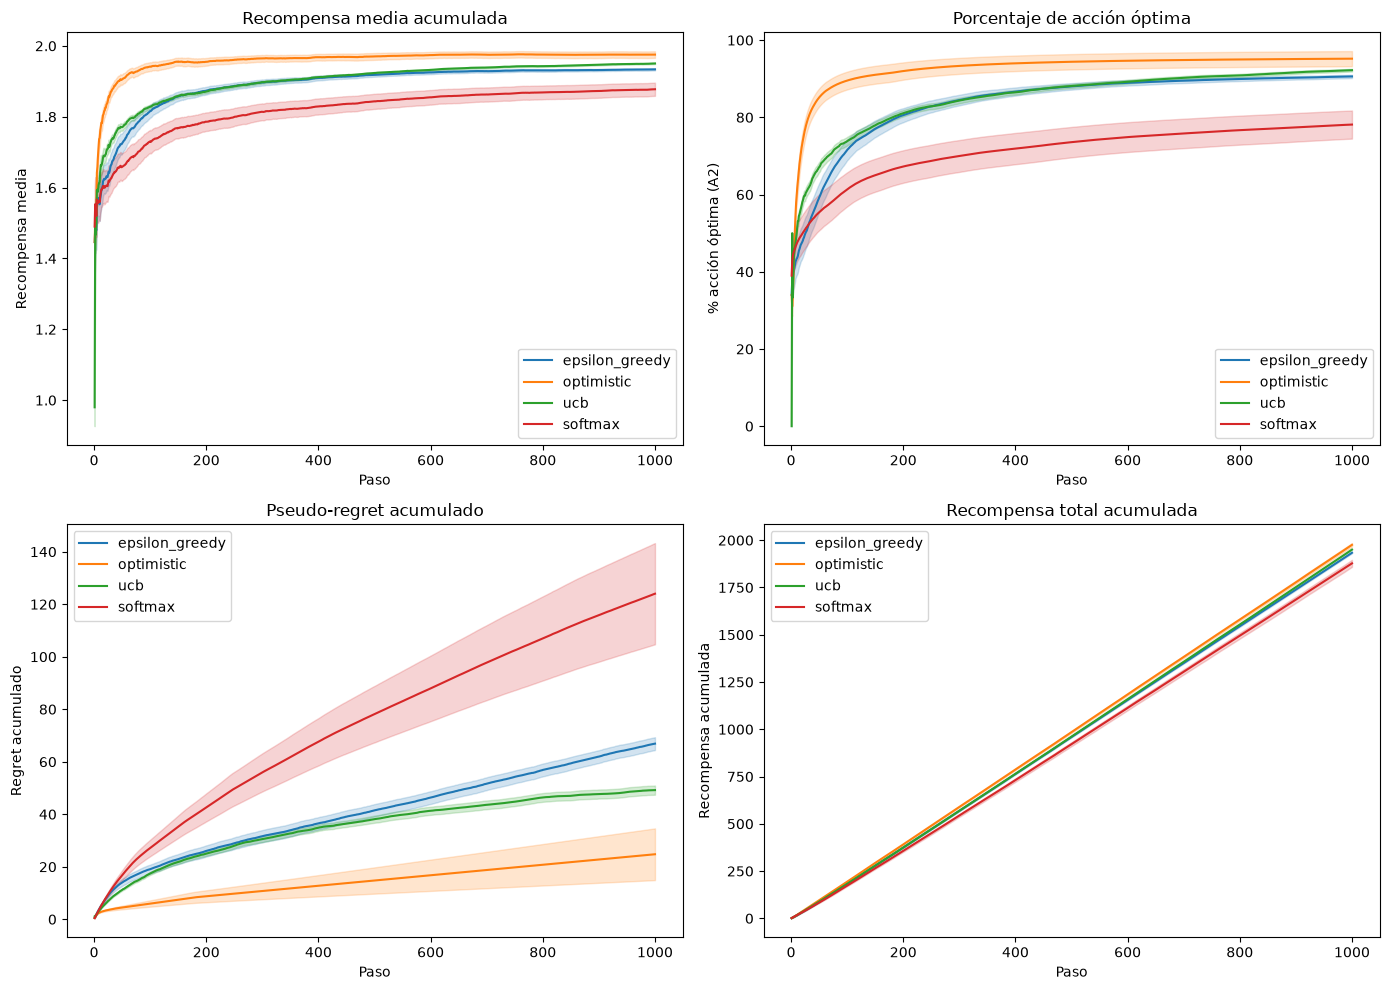

In [10]:
# --- Tabla resumen ---
# Para cada algoritmo tomamos el ÚLTIMO paso de cada corrida (columna -1)
# y promediamos sobre las N_RUNS corridas.
summary_rows = []
for name, metrics in results.items():
    final_avg_reward_per_run = metrics["cumulative_average"][:, -1]
    final_opt_rate_per_run = metrics["optimal_rate"][:, -1]
    final_regret_per_run = metrics["regret"][:, -1]

    summary_rows.append(
        {
            "algoritmo": name,
            "recompensa_final_promedio": final_avg_reward_per_run.mean(),
            "opt_action_rate_final_%": final_opt_rate_per_run.mean(),
            "regret_final_promedio": final_regret_per_run.mean(),
            # SEM = desviación estándar entre corridas / raíz(N_RUNS):
            # mide qué tan preciso es el promedio anterior.
            "recompensa_final_sem": final_avg_reward_per_run.std(ddof=1) / np.sqrt(N_RUNS),
        }
    )

summary_df = pd.DataFrame(summary_rows).set_index("algoritmo")
print("Medida de variabilidad utilizada: error estándar de la media (SEM = std entre corridas / sqrt(N_RUNS)).")
display(summary_df)

# --- Cuatro gráficas obligatorias ---
# Colores fijos por algoritmo, iguales en las cuatro gráficas, para
# poder identificar cada curva de un vistazo.
ALGO_COLORS = {
    "epsilon_greedy": "tab:blue",
    "optimistic": "tab:orange",
    "ucb": "tab:green",
    "softmax": "tab:red",
}

steps = np.arange(1, HORIZON + 1)


def plot_metric(ax, metric_key, title, ylabel):
    """Dibuja, para cada algoritmo, la media entre corridas y una banda
    de +/- 1 SEM (error estándar de la media) alrededor de esa media."""
    for name, color in ALGO_COLORS.items():
        data = results[name][metric_key]  # forma (N_RUNS, HORIZON)
        mean_curve = data.mean(axis=0)
        sem_curve = data.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
        ax.plot(steps, mean_curve, label=name, color=color)
        ax.fill_between(
            steps, mean_curve - sem_curve, mean_curve + sem_curve, color=color, alpha=0.2
        )
    ax.set_title(title)
    ax.set_xlabel("Paso")
    ax.set_ylabel(ylabel)
    ax.legend()


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_metric(axes[0, 0], "cumulative_average", "Recompensa media acumulada", "Recompensa media")
plot_metric(axes[0, 1], "optimal_rate", "Porcentaje de acción óptima", "% acción óptima (A2)")
plot_metric(axes[1, 0], "regret", "Pseudo-regret acumulado", "Regret acumulado")
plot_metric(axes[1, 1], "cumulative_reward", "Recompensa total acumulada", "Recompensa acumulada")

plt.tight_layout()
plt.show()

## 11. Sensibilidad de hiperparámetros

Compara los valores de ε, Q0, c y τ indicados en el enunciado.

Sensibilidad de epsilon (epsilon-greedy, Q0 = 0):


,recompensa_final_promedio,opt_action_rate_final_%,regret_final_promedio
epsilon,,,
0.01,1.825272,79.290000,177.533333
0.10,1.935170,89.553333,71.900000
0.30,1.848221,79.196667,154.650000



Sensibilidad de Q0 (inicio optimista, epsilon = 0):


,recompensa_final_promedio,opt_action_rate_final_%,regret_final_promedio
Q0,,,
2.0,1.952955,89.66,52.250000
5.0,1.964688,92.26,39.266667
10.0,1.964688,92.26,39.266667



Sensibilidad de c (UCB):


,recompensa_final_promedio,opt_action_rate_final_%,regret_final_promedio
c,,,
0.5,1.998649,99.270000,4.750000
1.0,1.989209,97.650000,14.766667
2.0,1.956483,92.810000,46.233333
4.0,1.873265,79.636667,131.516667



Sensibilidad de la temperatura (Softmax):


,recompensa_final_promedio,opt_action_rate_final_%,regret_final_promedio
temperature,,,
0.05,1.741016,63.296667,266.850000
0.20,1.870902,75.153333,137.833333
0.50,1.807095,70.166667,198.216667
1.00,1.665804,50.670000,341.316667


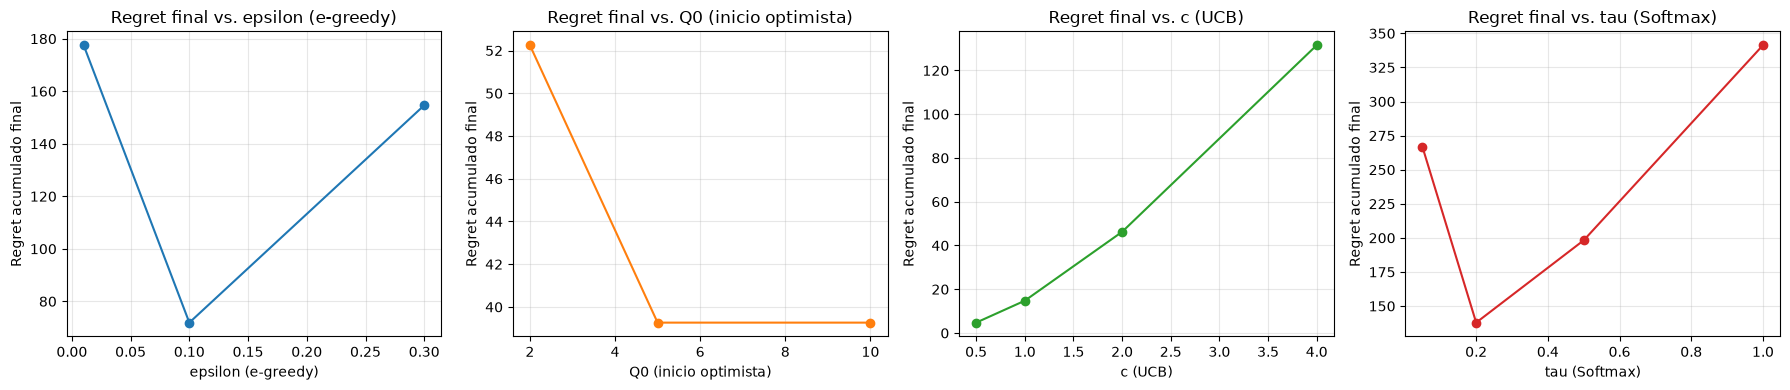


SEM de la recompensa final promedio vs. numero de corridas:


,n_runs,sem
0,10,0.006190
1,50,0.003008
2,100,0.003012
3,1000,0.000892
4,4000,0.000448
5,9000,0.000297


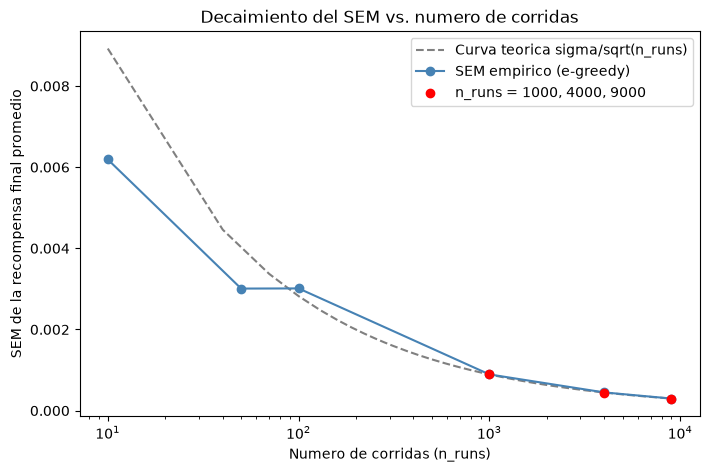

In [11]:
# --- Sensibilidad de hiperparametros ---
# Usamos menos corridas que la comparacion principal (100) para que este
# analisis sea mas rapido; 30 corridas siguen siendo suficientes para ver la
# tendencia, y mantenemos constantes el horizonte, la semilla base y el entorno.
SENSITIVITY_RUNS = 30


def evaluate_config(run_fn, n_runs=SENSITIVITY_RUNS):
    """Ejecuta n_runs corridas de un algoritmo ya configurado (run_fn solo
    recibe la semilla) y promedia las metricas finales entre corridas."""
    final_rewards = np.zeros(n_runs)
    final_opt_rates = np.zeros(n_runs)
    final_regrets = np.zeros(n_runs)

    for i in range(n_runs):
        run_df = run_fn(SEED + i)
        rewards = run_df["reward"].to_numpy()
        actions = run_df["action"].to_numpy()

        final_rewards[i] = cumulative_average(rewards)[-1]
        final_opt_rates[i] = optimal_action_rate(actions, optimal_arm)[-1]
        final_regrets[i] = cumulative_regret(actions, MEANS)[-1]

    return {
        "recompensa_final_promedio": final_rewards.mean(),
        "opt_action_rate_final_%": final_opt_rates.mean(),
        "regret_final_promedio": final_regrets.mean(),
    }


# --- Sensibilidad de epsilon (epsilon-greedy con Q0 = 0) ---
# Valores pedidos en el enunciado: 0.01, 0.10 y 0.30.
epsilon_rows = []
for eps in [0.01, 0.10, 0.30]:
    metrics = evaluate_config(
        lambda seed, eps=eps: run_epsilon_greedy(
            epsilon=eps, initial_value=0.0, horizon=HORIZON, seed=seed
        )
    )
    epsilon_rows.append({"epsilon": eps, **metrics})
epsilon_sensitivity_df = pd.DataFrame(epsilon_rows).set_index("epsilon")
print("Sensibilidad de epsilon (epsilon-greedy, Q0 = 0):")
display(epsilon_sensitivity_df)

# --- Sensibilidad de Q0 (inicio optimista con epsilon = 0) ---
# Valores pedidos en el enunciado: 2, 5 y 10.
# Con epsilon = 0 no hay exploracion aleatoria: la UNICA fuente de exploracion
# es que tan por encima de la mejor recompensa real (2.0) queden las
# estimaciones iniciales. Q0 = 2 apenas empata con el optimo real, asi que
# casi no induce exploracion; Q0 = 10 la exagera y desperdicia pasos iniciales.
q0_rows = []
for q0 in [2.0, 5.0, 10.0]:
    metrics = evaluate_config(
        lambda seed, q0=q0: run_epsilon_greedy(
            epsilon=0.0, initial_value=q0, horizon=HORIZON, seed=seed
        )
    )
    q0_rows.append({"Q0": q0, **metrics})
q0_sensitivity_df = pd.DataFrame(q0_rows).set_index("Q0")
print("\nSensibilidad de Q0 (inicio optimista, epsilon = 0):")
display(q0_sensitivity_df)

# --- Sensibilidad de c (UCB) ---
# Valores pedidos en el enunciado: 0.5, 1 y 2. Agregamos c = 4 para confirmar
# que la tendencia se mantiene fuera del rango solicitado.
c_rows = []
for c_value in [0.5, 1.0, 2.0, 4.0]:
    metrics = evaluate_config(
        lambda seed, c_value=c_value: run_ucb(c=c_value, horizon=HORIZON, seed=seed)
    )
    c_rows.append({"c": c_value, **metrics})
c_sensitivity_df = pd.DataFrame(c_rows).set_index("c")
print("\nSensibilidad de c (UCB):")
display(c_sensitivity_df)

# --- Sensibilidad de la temperatura tau (Softmax) ---
# Valores pedidos en el enunciado: 0.05, 0.20 y 1.0. Agregamos tau = 0.50
# como punto intermedio para ver mejor la forma de la curva.
temperature_rows = []
for temperature in [0.05, 0.20, 0.50, 1.00]:
    metrics = evaluate_config(
        lambda seed, temperature=temperature: run_softmax(
            temperature=temperature, horizon=HORIZON, seed=seed
        )
    )
    temperature_rows.append({"temperature": temperature, **metrics})
temperature_sensitivity_df = pd.DataFrame(temperature_rows).set_index("temperature")
print("\nSensibilidad de la temperatura (Softmax):")
display(temperature_sensitivity_df)


# --- Grafica comparativa de la sensibilidad ---
# Una fila por hiperparametro, mostrando como cambia el regret final.
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sensitivity_plots = [
    (epsilon_sensitivity_df, "epsilon (e-greedy)", "tab:blue"),
    (q0_sensitivity_df, "Q0 (inicio optimista)", "tab:orange"),
    (c_sensitivity_df, "c (UCB)", "tab:green"),
    (temperature_sensitivity_df, "tau (Softmax)", "tab:red"),
]

for ax, (sens_df, label, color) in zip(axes, sensitivity_plots):
    ax.plot(sens_df.index, sens_df["regret_final_promedio"], "o-", color=color)
    ax.set_title(f"Regret final vs. {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Regret acumulado final")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --- Experimento: error estandar de la media (SEM) vs. numero de corridas ---
# Usamos la configuracion base de epsilon-greedy (epsilon=0.10, Q0=0).
# Para no pagar el costo de construir un DataFrame de 1.000 filas en cada
# una de las miles de corridas, usamos una version "ligera" que solo
# devuelve la recompensa media final de la corrida (equivalente a
# cumulative_average(rewards)[-1], pero sin guardar todo el historial).
def epsilon_greedy_final_avg_reward(*, epsilon, initial_value, horizon, seed):
    bandit_run = GaussianBandit(MEANS, STDS, seed=seed)
    rng = np.random.default_rng(seed)
    n_arms = bandit_run.n_arms
    q_values = np.full(n_arms, float(initial_value))
    counts = np.zeros(n_arms, dtype=int)
    total_reward = 0.0

    for _ in range(horizon):
        if rng.random() < epsilon:
            action = int(rng.integers(n_arms))
        else:
            action = random_argmax(q_values, rng)
        reward = bandit_run.pull(action)
        counts[action] += 1
        q_values[action] = incremental_update(q_values[action], reward, counts[action])
        total_reward += reward

    return total_reward / horizon


N_RUNS_GRID = [10, 50, 100, 1_000, 4_000, 9_000]

# Generamos de una sola vez el mayor numero de corridas necesario (9.000) y
# luego, para cada tamano de la grilla, tomamos solo el primer n_runs de
# ese arreglo: asi no repetimos trabajo entre puntos de la grilla.
max_runs = max(N_RUNS_GRID)
final_rewards_pool = np.array(
    [
        epsilon_greedy_final_avg_reward(
            epsilon=0.10, initial_value=0.0, horizon=HORIZON, seed=SEED + i
        )
        for i in range(max_runs)
    ]
)

sem_rows = []
for n_runs in N_RUNS_GRID:
    subset = final_rewards_pool[:n_runs]
    # SEM = desviacion estandar muestral (ddof=1) entre corridas / raiz(n_runs).
    sem = subset.std(ddof=1) / np.sqrt(n_runs)
    sem_rows.append({"n_runs": n_runs, "sem": sem})
sem_df = pd.DataFrame(sem_rows)
print("\nSEM de la recompensa final promedio vs. numero de corridas:")
display(sem_df)

# Usamos la desviacion estandar entre las 9.000 corridas como estimador de
# sigma para dibujar la curva teorica sigma / sqrt(n_runs).
sigma_hat = final_rewards_pool.std(ddof=1)

n_runs_grid_fine = np.linspace(min(N_RUNS_GRID), max(N_RUNS_GRID), 300)
theoretical_sem = sigma_hat / np.sqrt(n_runs_grid_fine)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(n_runs_grid_fine, theoretical_sem, color="gray", linestyle="--", label="Curva teorica sigma/sqrt(n_runs)")
ax.plot(sem_df["n_runs"], sem_df["sem"], "o-", color="steelblue", label="SEM empirico (e-greedy)")

highlight_n_runs = [1_000, 4_000, 9_000]
highlight_sem = sigma_hat / np.sqrt(highlight_n_runs)
ax.scatter(highlight_n_runs, highlight_sem, color="red", zorder=5, label="n_runs = 1000, 4000, 9000")

ax.set_xscale("log")
ax.set_xlabel("Numero de corridas (n_runs)")
ax.set_ylabel("SEM de la recompensa final promedio")
ax.set_title("Decaimiento del SEM vs. numero de corridas")
ax.legend()
plt.show()

# Dato factual (curva teorica sigma/sqrt(n_runs)):
# sem(1000) = sigma_hat/sqrt(1000)
# sem(4000) = sigma_hat/sqrt(4000)  -> la mitad de sem(1000), porque sqrt(4000/1000) = 2
# sem(9000) = sigma_hat/sqrt(9000)  -> un tercio de sem(1000), porque sqrt(9000/1000) = 3

## 12. Interpretación

Responde las nueve preguntas del enunciado con evidencia de tus resultados.

**1. ¿Qué algoritmo obtuvo mayor recompensa acumulada?**

El inicio optimista (ε = 0, Q0 = 5), con una recompensa media final de 1.9754 sobre un máximo de 2.0. Le siguen UCB con c = 2 (1.9504), ε-greedy con ε = 0.10 (1.9337) y softmax con τ = 0.20 (1.8776). Todos sobre 100 corridas de 1.000 pasos con las mismas semillas.

**2. ¿Cuál identificó más rápido el brazo óptimo?**

El inicio optimista, que terminó jugando A2 el 95.2 % de las veces, seguido de UCB (92.2 %). Ambos fuerzan una exploración inicial casi explotadora  UCB prueba los tres brazos una vez antes de aplicar su fórmula, y el inicio optimista los recorre porque cualquier brazo jugado "decepciona" frente a su Q inflado. La prueba corta de la Sección 5 lo muestra: en apenas 20 pasos ya había probado los tres brazos y jugaba A2 en 18 de ellos. ε-greedy (90.6 %) depende de desempates aleatorios y tarda un poco más; softmax es el más lento (78.1 %).

**3. ¿Cuál obtuvo menor regret final?**

Con los hiperparámetros base, el inicio optimista (24.77), seguido de UCB (49.20), ε-greedy (66.90) y softmax (124.02). Sin embargo, la mejor configuración de todo el experimento apareció en el análisis de sensibilidad: UCB con c = 0.5, con un regret de apenas 4.75 y 99.27 % de acción óptima, cinco veces mejor que el inicio optimista base.

**4. ¿Qué comportamiento produjo el inicio optimista?**

Al inicializar Q(a) = 5, muy por encima de la mejor recompensa esperada (2.0), todo brazo que se juega baja su estimación mientras los no probados siguen pareciendo mejores. Eso genera un barrido inicial de todos los brazos sin necesidad de acciones aleatorias.

El análisis de Q0 mostro que  Q0 = 5 y Q0 = 10 dan resultados idénticos (regret 39.27, 92.26 % de acción óptima en ambos). La razón es la actualización por media incremental en el primer tirón de un brazo, Q ← Q + (R − Q)/1 = R, es decir, el valor inicial se borra por completo tras una sola jugada. Por eso Q0 solo importa por un hecho binario —si está o no por encima de las recompensas reales, no por su magnitud. Con Q0 = 2, que apenas empata con la media de A2 y queda por debajo de muchas recompensas de A3, el efecto se debilita y el regret sube a 52.25. Esto también explica por qué la exploración del inicio optimista es "de una sola vez" y se agota rápido: no hay nada que la sostenga después del barrido inicial.

**5. ¿Cómo cambia UCB al modificar c?**

El regret creció de forma monótona al aumentar c: 4.75 (c = 0.5) → 14.77 (c = 1) → 46.23 (c = 2) → 131.52 (c = 4). El término c·√(ln t / N(a)) es un bono de incertidumbre: mide cuánto vale la pena volver a un brazo poco probado. Con solo tres brazos y medias bien separadas (1.0, 2.0, 1.5) hay poco que averiguar, así que un c grande obliga a revisitar brazos que ya se sabían malos —sobre todo A3, cuya alta varianza mantiene su incertidumbre elevada— y desperdicia pasos del horizonte.

**6. ¿Cómo cambia Softmax al modificar la temperatura?**

El efecto no fue monótono: el regret pasó de 266.85 (τ = 0.05) a 137.83 (τ = 0.20), subió a 198.22 (τ = 0.50) y se disparó a 341.32 (τ = 1.0). Hay un punto óptimo intermedio cerca de τ = 0.20.

Los dos extremos fallan por razones opuestas. Con τ muy baja, los logits Q(a)/τ se disparan y la política se vuelve casi determinista sobre estimaciones que al principio son puro ruido: el algoritmo se encierra en un brazo antes de tener información confiable. Con τ = 1.0 ocurre lo contrario: las probabilidades se aplanan tanto que la tasa de acción óptima cae a 50.7 %, no muy lejos del 33 % de elegir al azar, y sigue explorando incluso cuando ya sabe cuál es el mejor brazo.

**7. ¿Cuál estrategia fue más sensible a la alta varianza de A3?**

Softmax. Con los hiperparámetros base tuvo el menor porcentaje de acción óptima (78.1 %) y el mayor regret (124.02) de las cuatro estrategias. Su probabilidad de elegir un brazo depende directamente de las diferencias entre los Q(a), así que una racha afortunada de A3 (σ = 1.5, tres veces la de los otros brazos) se traduce de inmediato en más probabilidad de volver a jugarlo. A diferencia de UCB, softmax no distingue entre "este brazo parece bueno" y "de este brazo todavía sé poco": confunde suerte con calidad.

**8. ¿Existe un algoritmo ganador para todas las métricas y horizontes?**

No. Con los hiperparámetros base el inicio optimista domina las tres métricas, pero al ajustar c, UCB con c = 0.5 lo supera ampliamente (regret 4.75 frente a 24.77). Es decir, el ranking depende más del hiperparámetro que del algoritmo.

Además, el horizonte importa. ε-greedy y softmax mantienen una tasa de exploración fija que no decae, así que su regret crece de forma aproximadamente lineal y seguiría empeorando en horizontes más largos. UCB reduce su exploración conforme N(a) crece (cota de regret logarítmica), y el inicio optimista deja de explorar del todo una vez agotado el barrido inicial: eso lo hace eficiente aquí, pero frágil si el ruido inicial lo engaña, porque no tiene mecanismo para corregirse después.

**9. ¿Qué método recomendarías y bajo qué condiciones?**

Para un problema estacionario como este recomiendo UCB con un c pequeño (0.5–1): fue la mejor configuración de todo el experimento en las tres métricas y su exploración decae de forma controlada en lugar de depender de un parámetro fijo o de un empujón inicial que se agota.

La condición importante es que el entorno sea estacionario. Si las medias cambiaran con el tiempo, tanto UCB como el inicio optimista quedarían mal parados: el primero deja de explorar brazos que ya probó mucho, y el segundo pierde su optimismo tras el primer barrido. Ahí sería preferible ε-greedy con ε fijo —justo la exploración permanente que aquí resulta un desperdicio— o una versión con paso constante α en lugar de media incremental.

El inicio optimista sigue siendo una buena opción por su simplicidad: no agrega hiperparámetros reales (basta con que Q0 supere el máximo esperado) y funcionó muy bien. Softmax es el que menos recomendaría en este problema: fue el más débil con los parámetros base y el más sensible al ruido de A3.

## 13. Uso de inteligencia artificial

**Herramienta utilizada:** Claude (Anthropic), en chat para dudas conceptuales y como agente de codificación en VS Code. se anadieron pequenos snippets de codigo en cada celda para entender


**Prompts o preguntas principales:**
1. Diferencia entre implementar un entorno propio y usar el GaussianBandit del repositorio (brazos como índices).
2. Cómo estabilizar numéricamente el softmax y cómo hacer desempates aleatorios en argmax.
3. Por qué se promedian ≥100 corridas y cómo el error decae como 1/√(n_corridas).
4. Implementación de los cuatro algoritmos, la comparación principal y el análisis de sensibilidad.

**Sugerencias recibidas:** usar GaussianBandit y las métricas suministradas en lugar de un entorno propio; softmax con resta del máximo; desempate aleatorio; promediar sobre 100 corridas con semillas distintas y reportar variabilidad; experimento del SEM ∝ 1/√n para justificar el número de corridas.



**Forma de validación:** `pytest` en verde desde la raíz; "Restart Kernel and Run All Cells" sin errores; verificación de que las curvas coinciden con lo esperado (A2, índice 1, como brazo óptimo); revisión del código celda por celda.

## 14. Conclusiones

1. El inicio optimista fue la mejor de las cuatro estrategias base, y lo logró sin usar aleatoriedad. Obtuvo la mayor recompensa media (1.9754 de un máximo de 2.0), el mayor porcentaje de acción óptima (95.2 %) y el menor regret (24.77). Su exploración no viene de un parámetro de azar sino del propio sesgo inicial de las estimaciones, que se corrige solo a medida que el algoritmo aprende.

2. El hiperparámetro pesó más que la elección del algoritmo.UCB con c = 2 quedó segundo (regret 49.20), pero con c = 0.5 se convirtió en la mejor configuración de todo el experimento: regret 4.75 y 99.27 % de acción óptima, cinco veces mejor que el ganador base. Comparar algoritmos con valores arbitrarios compara configuraciones, no ideas.

3. Más exploración no es mejor exploración. En UCB el regret creció de forma monótona con c (4.75 → 14.77 → 46.23 → 131.52 para c = 0.5, 1, 2 y 4). Con solo tres brazos y medias bien separadas hay poco que averiguar, y cada paso gastado en un brazo ya descartado es una pérdida directa. En softmax el efecto fue no monótono, con un óptimo intermedio en τ = 0.20 y ambos extremos peores: el problema no es explorar mucho o poco, sino cuándo.

4. Con actualización por media incremental, la magnitud de Q0 es irrelevante.** Q0 = 5 y Q0 = 10 produjeron resultados idénticos (regret 39.27), porque el primer tirón de cada brazo hace Q ← R y borra el valor inicial por completo. Lo único que importa es si Q0 supera o no las recompensas reales: con Q0 = 2 el efecto se debilita y el regret sube a 52.25. Esto explica por qué la exploración del inicio optimista se agota tras el barrido inicial y por qué sería inservible en un entorno no estacionario.

5. Softmax fue el más vulnerable al ruido de A3. Con los parámetros base tuvo el peor porcentaje de acción óptima (78.1 %) y el peor regret (124.02). Al depender solo de las diferencias entre estimaciones, traduce cualquier racha de suerte de A3 (σ = 1.5) en más probabilidad de repetirlo. UCB, en cambio, separa "qué tan bueno parece" de "qué tan seguro estoy", y esa distinción es justamente lo que evita confundir suerte con calidad.

6. Las 100 corridas exigidas por el reto son suficientes, y se puede demostrar.El SEM decayó como 1/√n: de 1.000 a 4.000 corridas se redujo a la mitad (0.000892 → 0.000448) y a 9.000 a un tercio (0.000297), siguiendo la curva teórica σ/√n. Con 100 corridas el error de medición (≈0.003–0.019 según el algoritmo) ya es un orden de magnitud menor que las diferencias entre estrategias (≈0.06–0.10), así que multiplicar el cómputo afinaría decimales sin cambiar ninguna conclusión.